In [2]:
import pandas as pd
import plotnine as p9
import numpy as np
import scanpy as sc

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mplpatches

In [4]:
p9.options.dpi=300
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype']='none'

In [5]:
df_10x_3pRNA=pd.read_csv(data_dir+'/barnyard_10x/intergenicUMI_summary.csv',header=0)

In [6]:
df_10x_3pRNA['experiment']='Chromium_cell'

In [7]:
df_OAK150k=pd.read_csv(data_dir+'/barnyard_OAK150kali1/intergenicUMI_summary.csv',header=0)

In [8]:
df_OAK150k['experiment']='OAK'

In [9]:
df_multiome=pd.read_csv(data_dir+'/K562_multiome10x/intergenicUMI_summary.csv',header=0)

In [10]:
df_multiome['experiment']='Chromium_nucleus'

In [11]:
df_compare=pd.concat([df_10x_3pRNA[df_10x_3pRNA.call=='GRCh38'][['cell_bc','Intergenic_UMI_ratio','experiment']],df_OAK150k[df_10x_3pRNA.call=='GRCh38'][['cell_bc','Intergenic_UMI_ratio','experiment']],df_multiome[['barcode','Intergenic_UMI_ratio','experiment']]],ignore_index=True)

/local/35843582/ipykernel_20127/1124767410.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.


In [12]:
df_compare['intergenic_frac']=df_compare['Intergenic_UMI_ratio']*100

In [14]:
df_compare.groupby('experiment')['intergenic_frac'].mean()

experiment
Chromium_cell        7.459627
Chromium_nucleus    23.234355
OAK                  7.690748
Name: intergenic_frac, dtype: float64

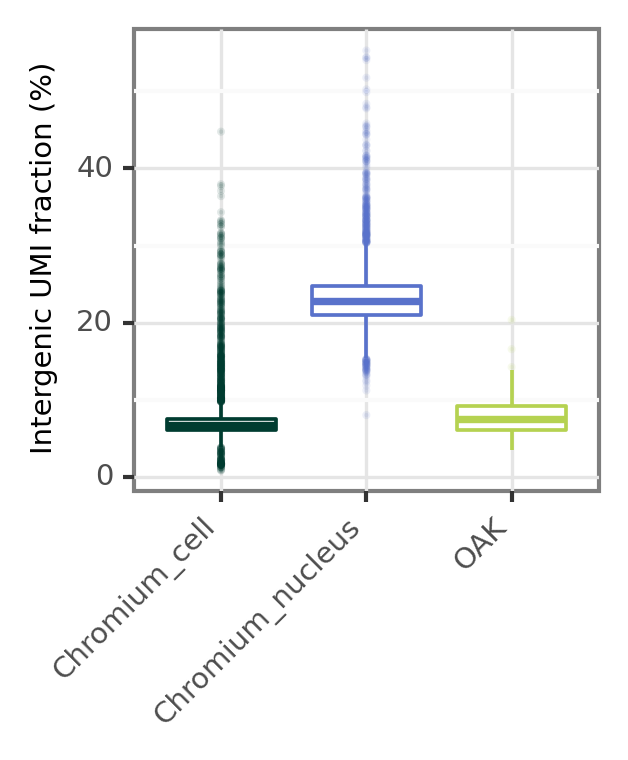

<ggplot: (2932113263246)>

In [31]:
plot=p9.ggplot(data=df_compare,
               mapping=p9.aes(x='experiment',y='intergenic_frac',color='experiment')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.1,outlier_size=0.1, show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.theme(figure_size=(2, 2),axis_text_x=p9.element_text(rotation = 45)) \
+ p9.xlab('') \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.ylab('Intergenic UMI fraction (%)') \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.scale_x_discrete(limits=['Chromium_cell','Chromium_nucleus','OAK']) \
+ p9.scale_color_manual(values = {'Chromium_cell':'#003C30','OAK':'#B5D251','Chromium_nucleus':'#5972CB'}) 


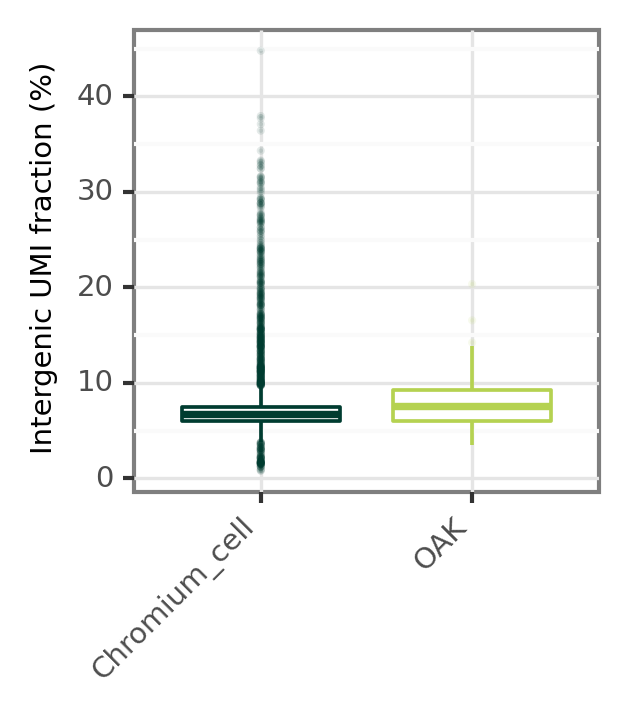

<ggplot: (2932113015836)>

In [27]:
plot=p9.ggplot(data=df_compare[df_compare.experiment.isin(['Chromium_cell','OAK'])],
               mapping=p9.aes(x='experiment',y='intergenic_frac',color='experiment')
              )
plot+ p9.geom_boxplot(outlier_alpha=0.1,outlier_size=0.1, show_legend=False) \
+ p9.themes.theme_bw() \
+ p9.theme(figure_size=(2, 2),axis_text_x=p9.element_text(rotation = 45)) \
+ p9.xlab('') \
+ p9.theme(axis_text_x=p9.element_text(angle = 45, hjust = 1)) \
+ p9.ylab('Intergenic UMI fraction (%)') \
+ p9.theme(text=p9.element_text(size=7)) \
+ p9.scale_x_discrete(limits=['Chromium_cell','OAK']) \
+ p9.scale_color_manual(values = {'Chromium_cell':'#003C30','OAK':'#B5D251'}) 
